In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from res import *

combined_mask : has schema Schema({'lod_level': UInt8, 'lod_code': String, 'face': String, 'i': UInt32, 'j': UInt32, 'row_id': UInt32}) and       additional information Parquet SCAN [C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33-Database-Refinement-Improved\data_products\combined_mask.parquet]
PROJECT */6 COLUMNS
ESTIMATED ROWS: 100728072
combined_atlas : has schema Schema({'face': String, 'i': UInt32, 'j': UInt32, 'uint8_reflectance': UInt8, '32bit_reflectance': Float32, 'positions_x': Float32, 'positions_y': Float32, 'positions_z': Float32}) and       additional information Parquet SCAN [C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33-Database-Refinement-Improved\data_products\combined_atlas.parquet]
PROJECT */8 COLUMNS
ESTIMATED ROWS: 402653184
mask_atlas_combined : has schema Schema({'lod_level': UInt8, 'lod_code': String, 'face': String, 'i': UInt32, 'j': UInt32, 'row_id': UInt32, 'uint8_reflectance': UInt8, '32bit_reflectance': Float32, 'positions_x'

In [2]:
bin_number = 1000
phi_bin_edges = np.geomspace(10, 1000, bin_number)

In [3]:
LAD_min = 4

a_min = np.pi * (LAD_min) ** 2
a_max = np.float32(boulder_agg_data.collect()["surface_area"].max()) * 1e6
q = 2.51 / 2
alphas = np.geomspace(1, 1e6, 1000)
alphas_hist = np.geomspace(1, 1e6, 100)

def sigma_sum(alphas, phis, phi_weights):

    return np.sum(np.where(
        (a_min < alphas[:, None] / phis[None, :]) & (alphas[:, None] / phis[None, :] < a_max),
        phi_weights[None, :] * (- q * phis[None, :] ** (q)) / (a_max ** (-q) - a_min  ** (-q)),
        0
    ), axis=1) / np.sum(phi_weights)

In [4]:
target = boulder_agg_data.filter(pl.col("longest_axis_diameter") * 1000 > LAD_min, pl.col("alpha") < 1e3).collect()
most = boulder_agg_data.filter(pl.col("longest_axis_diameter") * 1000 > LAD_min).collect()

most_ratios = most["longest_axis_diameter"].to_numpy() / most["surface_area"].to_numpy()
target_ratios = target["longest_axis_diameter"].to_numpy() / target["surface_area"].to_numpy()
most_ratios_clean = most_ratios[~np.isnan(most_ratios)]
target_ratios_clean = target_ratios[~np.isnan(target_ratios)]

bins = np.linspace(most_ratios_clean.min(), most_ratios_clean.max(), 100)

mean_p2std = most_ratios_clean.mean() + 2 * most_ratios_clean.std()

# plt.hist(most_ratios_clean, bins, label = "error", color = "C0")
# plt.hist(target_ratios_clean, bins, label = "error", color = "C1")
# plt.axvline(most_ratios_clean.mean(), label = "Mean", color = "C2")
# plt.axvline(most_ratios_clean.mean() + 2 * most_ratios_clean.std(), label = "Mean + 2 std", color = "C3")
# plt.legend()
# # plt.xscale("log")
# plt.yscale("log")


In [5]:
cleaned_data = boulder_agg_data.filter(
    pl.col("longest_axis_diameter") * 1000 > LAD_min,
    (pl.col("longest_axis_diameter") / pl.col("surface_area")) < mean_p2std
    )

In [6]:
combined_mask_no_merge.filter(pl.col("i") == 1).collect()

lod_level,lod_code,face,i,j,row_id
u8,str,str,u32,u32,u32
0,"""""","""negx""",1,1936,219331
0,"""""","""negx""",1,1937,219331
0,"""""","""negx""",1,1938,219331
0,"""""","""negx""",1,1939,219331
0,"""""","""negx""",1,1940,219331
…,…,…,…,…,…
4,"""BBBB""","""posz""",1,8064,447913
4,"""BBBB""","""posz""",1,8119,447992
4,"""BBBB""","""posz""",1,8120,447992


In [7]:
relative_alpha = (pl.col("alpha") / (2 ** (2*4 - 2 * pl.col("tile_lod_number"))
        ))

no_merge_sample = combined_mask_no_merge.group_by("row_id").agg(
    pl.len().alias("alpha"),
    pl.col("lod_level").first().alias("tile_lod_number")
).with_columns(
    relative_alpha.alias("relative_alpha")
).collect()["relative_alpha"].to_numpy()

sample = boulder_agg_data.collect().with_columns(
    relative_alpha.alias("relative_alpha")
)["relative_alpha"].to_numpy()

In [8]:
from scipy.stats import gaussian_kde
from scipy.interpolate import interp1d

# sample = boulder_agg_data.collect().with_columns(
#     (pl.col("alpha") / (2 ** (2*4 - 2 * pl.col("tile_lod_number"))
#         )).alias("relative_alpha")
# )["relative_alpha"].to_numpy()

log_sample = np.log(no_merge_sample[no_merge_sample > 5.5])
kde = gaussian_kde(log_sample)

S = lambda x : kde(np.log(x)) / (x * (x ** (-q)))

xs_grid = np.geomspace(no_merge_sample[no_merge_sample > 5.5].min(),
                       no_merge_sample.max(),
                       1000)

ys_grid = S(xs_grid)

# Interpolated fast version
S_fast = interp1d(
    xs_grid,
    ys_grid,
    kind="linear",
    bounds_error=False,
    fill_value=0.0
)

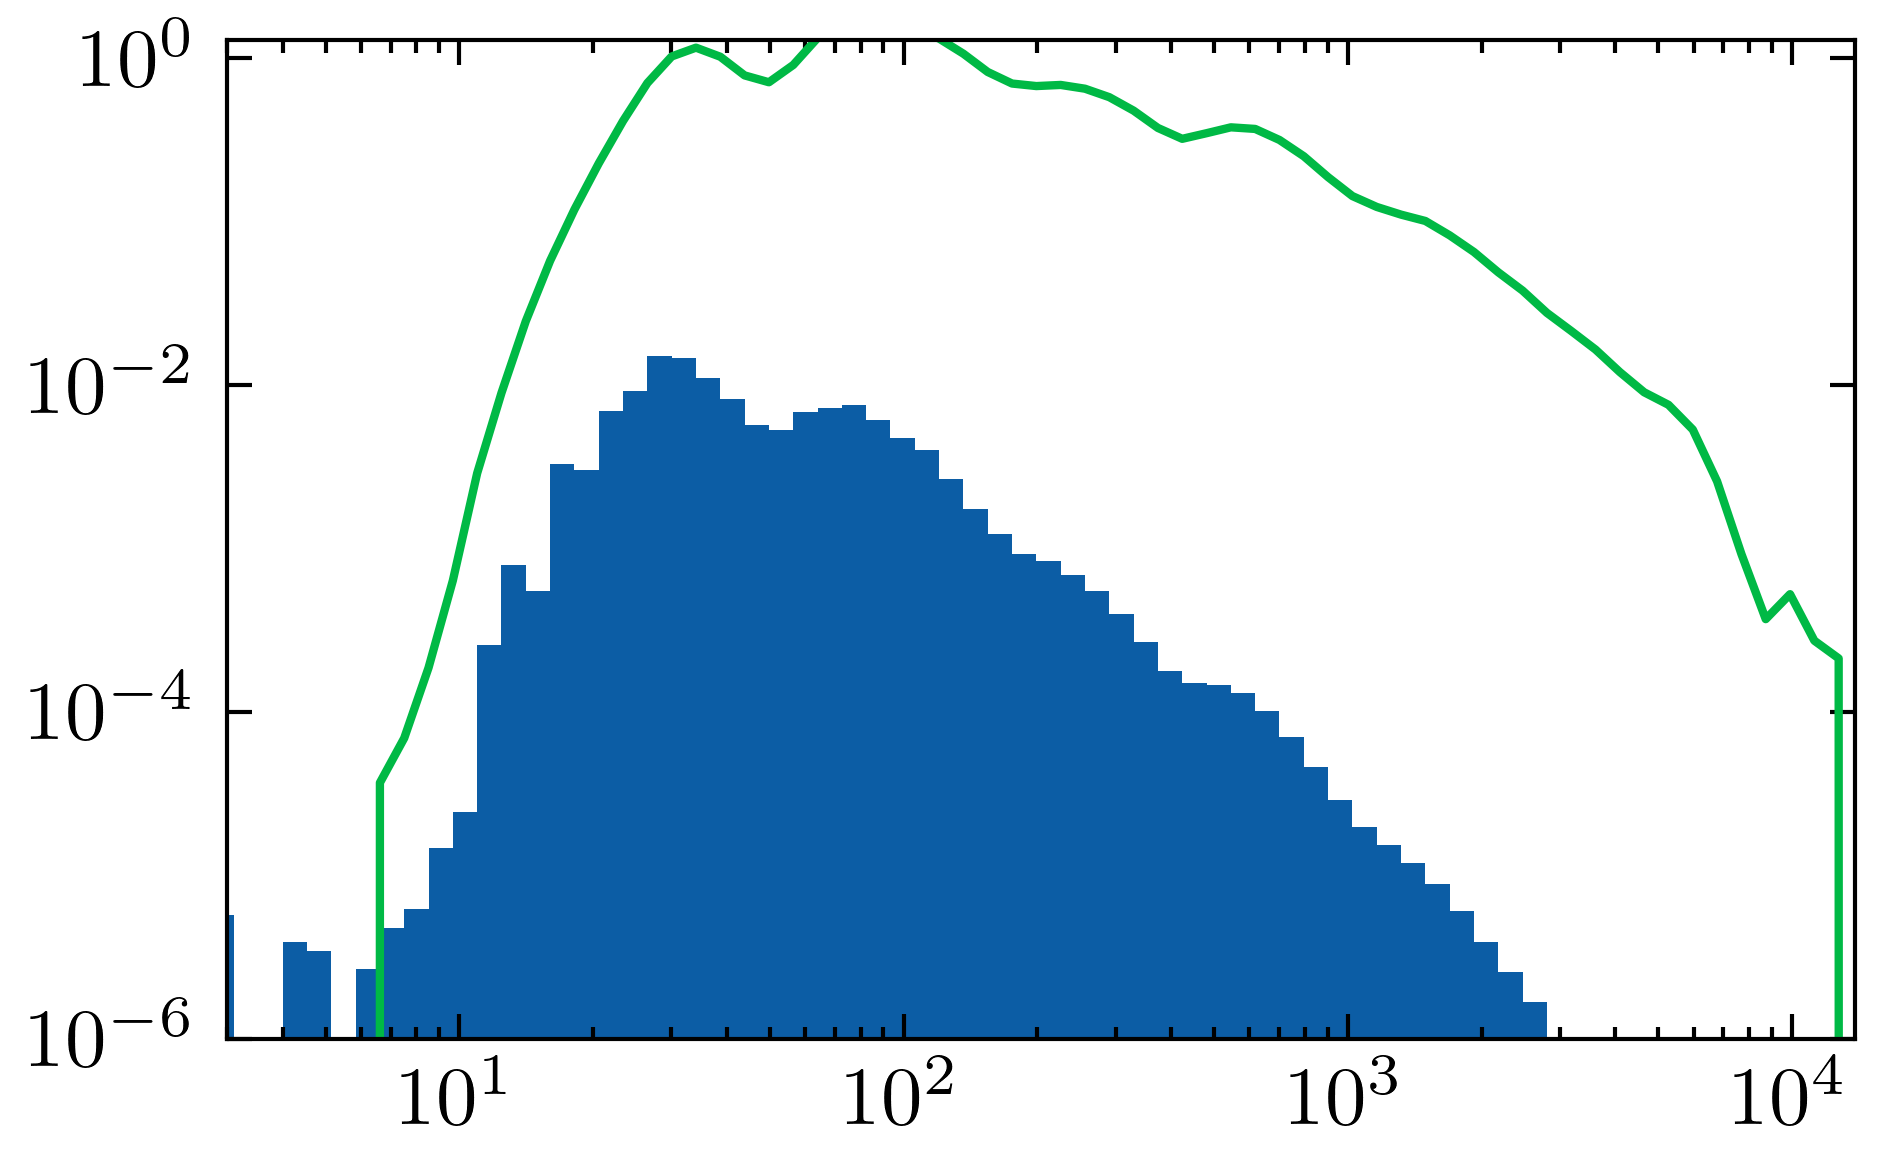

In [9]:
ralphas = np.geomspace(1, 512**2, 100)

plt.hist(no_merge_sample, ralphas, density=True)
plt.plot(ralphas, S_fast(ralphas))
plt.xlim(no_merge_sample.min(), no_merge_sample.max())
plt.ylim(1e-6, 1.3)
plt.xscale("log")
plt.yscale("log")

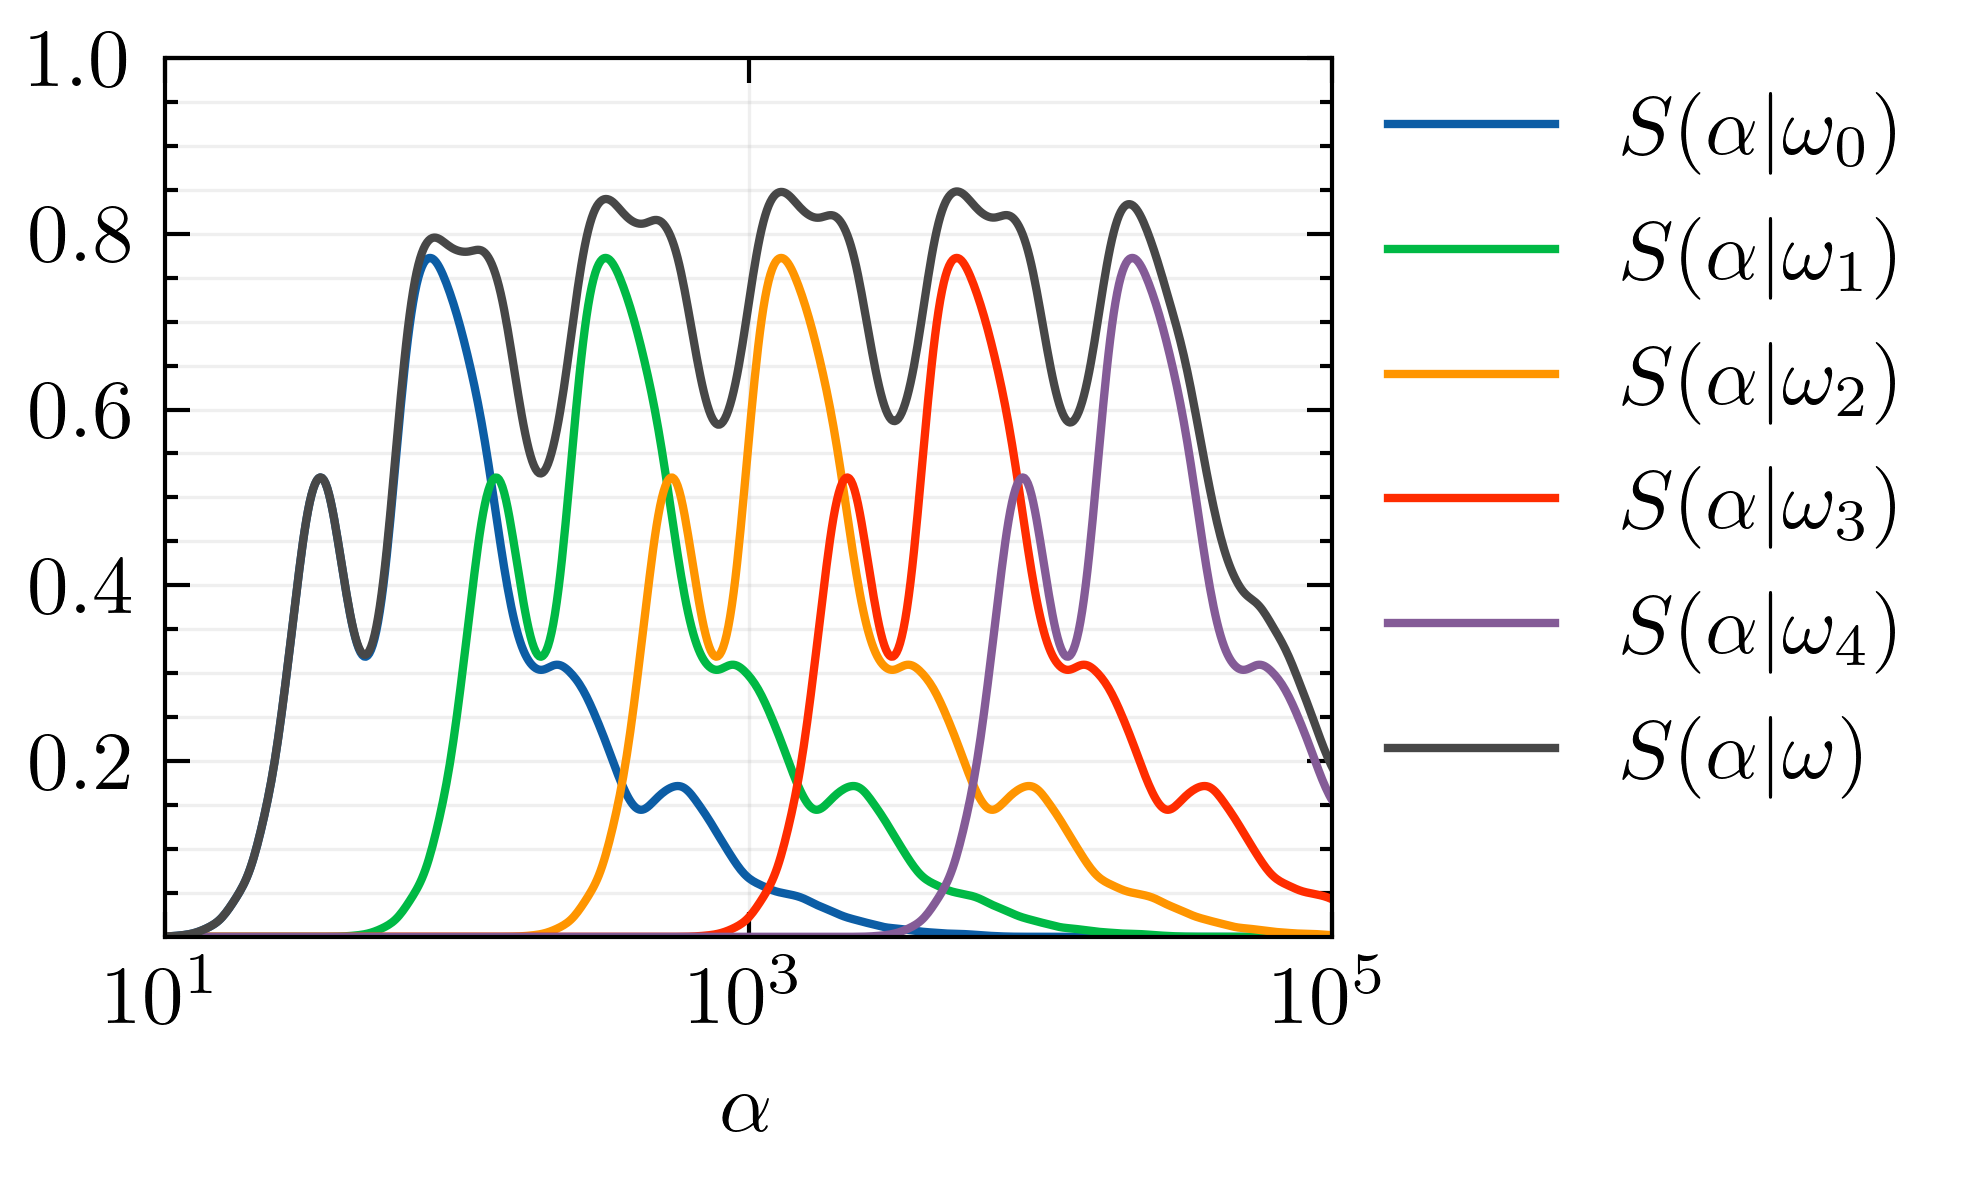

In [ ]:
effectiveness = 0.4354153058515187

for i in range(5):
    plt.plot(alphas, effectiveness * S_fast(alphas / (2 ** (2*i))), label = rf"$S(\alpha|\omega_{i})$")

total_s = 1 - np.prod([
    1 - effectiveness * S_fast(alphas / (2 ** (2*4 - 2*i))) for i in range(5)
], axis = 0)

plt.plot(alphas, total_s, label = r"$S(\alpha|\omega)$")
plt.ylim(1e-7, 1)
plt.xlabel(r"$\alpha$")
plt.xlim(1e1, 1e5)
plt.xscale("log")
plt.legend(loc='upper left',
          bbox_to_anchor=(1.02, 1),
          borderaxespad=0,
          frameon=False)
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.savefig("sensitivity_estimation.png")
plt.tight_layout()
plt.show()

In [11]:
from scipy import integrate
from functools import partial

S_un_norm = lambda x : kde(np.log(x)) / x

xs_grid = np.geomspace(sample[sample > 5.5].min(),
                       sample.max(),
                       1000)

ys_grid = S_un_norm(xs_grid)

S_fast_un_norm = interp1d(
    xs_grid,
    ys_grid,
    kind="linear",
    bounds_error=False,
    fill_value=0.0
)

def quad_logx(f, a, b):
    def transformed(t):
        x = np.exp(t)
        return f(np.array([x])) * x   # Jacobian factor

    return integrate.quad(transformed, np.log(a), np.log(b), limit=200, epsabs=1e-10, epsrel=1e-10)

def F(alphas, effectiveness, Q, g, q):
    S_estimate = lambda x : S_fast_un_norm(x) / (x ** (-q))
    total_p_alpha = (alphas ** (-q - 1)) * sigma_sum(alphas, g/3 * phi_bin_edges[:-1], Phi_counts_smoothed)
    total_s = 1 - np.prod([
        1 - 0.5 * S_estimate(alphas / (2 ** (2*4 - 2*i))) for i in range(5)
    ], axis = 0)

    total_s = 1 - np.prod([
        1 - effectiveness * S_fast(alphas / (2 ** (2*4 - 2*i))) for i in range(5)
    ], axis = 0)

    return Q * total_p_alpha * total_s

def F_norm(alphas, effectiveness, g, q):

    F_partial = partial(F, effectiveness = effectiveness, Q = 1, g = g, q = q)
    res, err = quad_logx(F_partial, 1e1, 1e5)
    return F(alphas, effectiveness, Q = 1 / res, g = g, q = q)


C:\Users\Joshu\AppData\Local\Temp\ipykernel_28536\740708052.py:25: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return integrate.quad(transformed, np.log(a), np.log(b), limit=200, epsabs=1e-10, epsrel=1e-10)


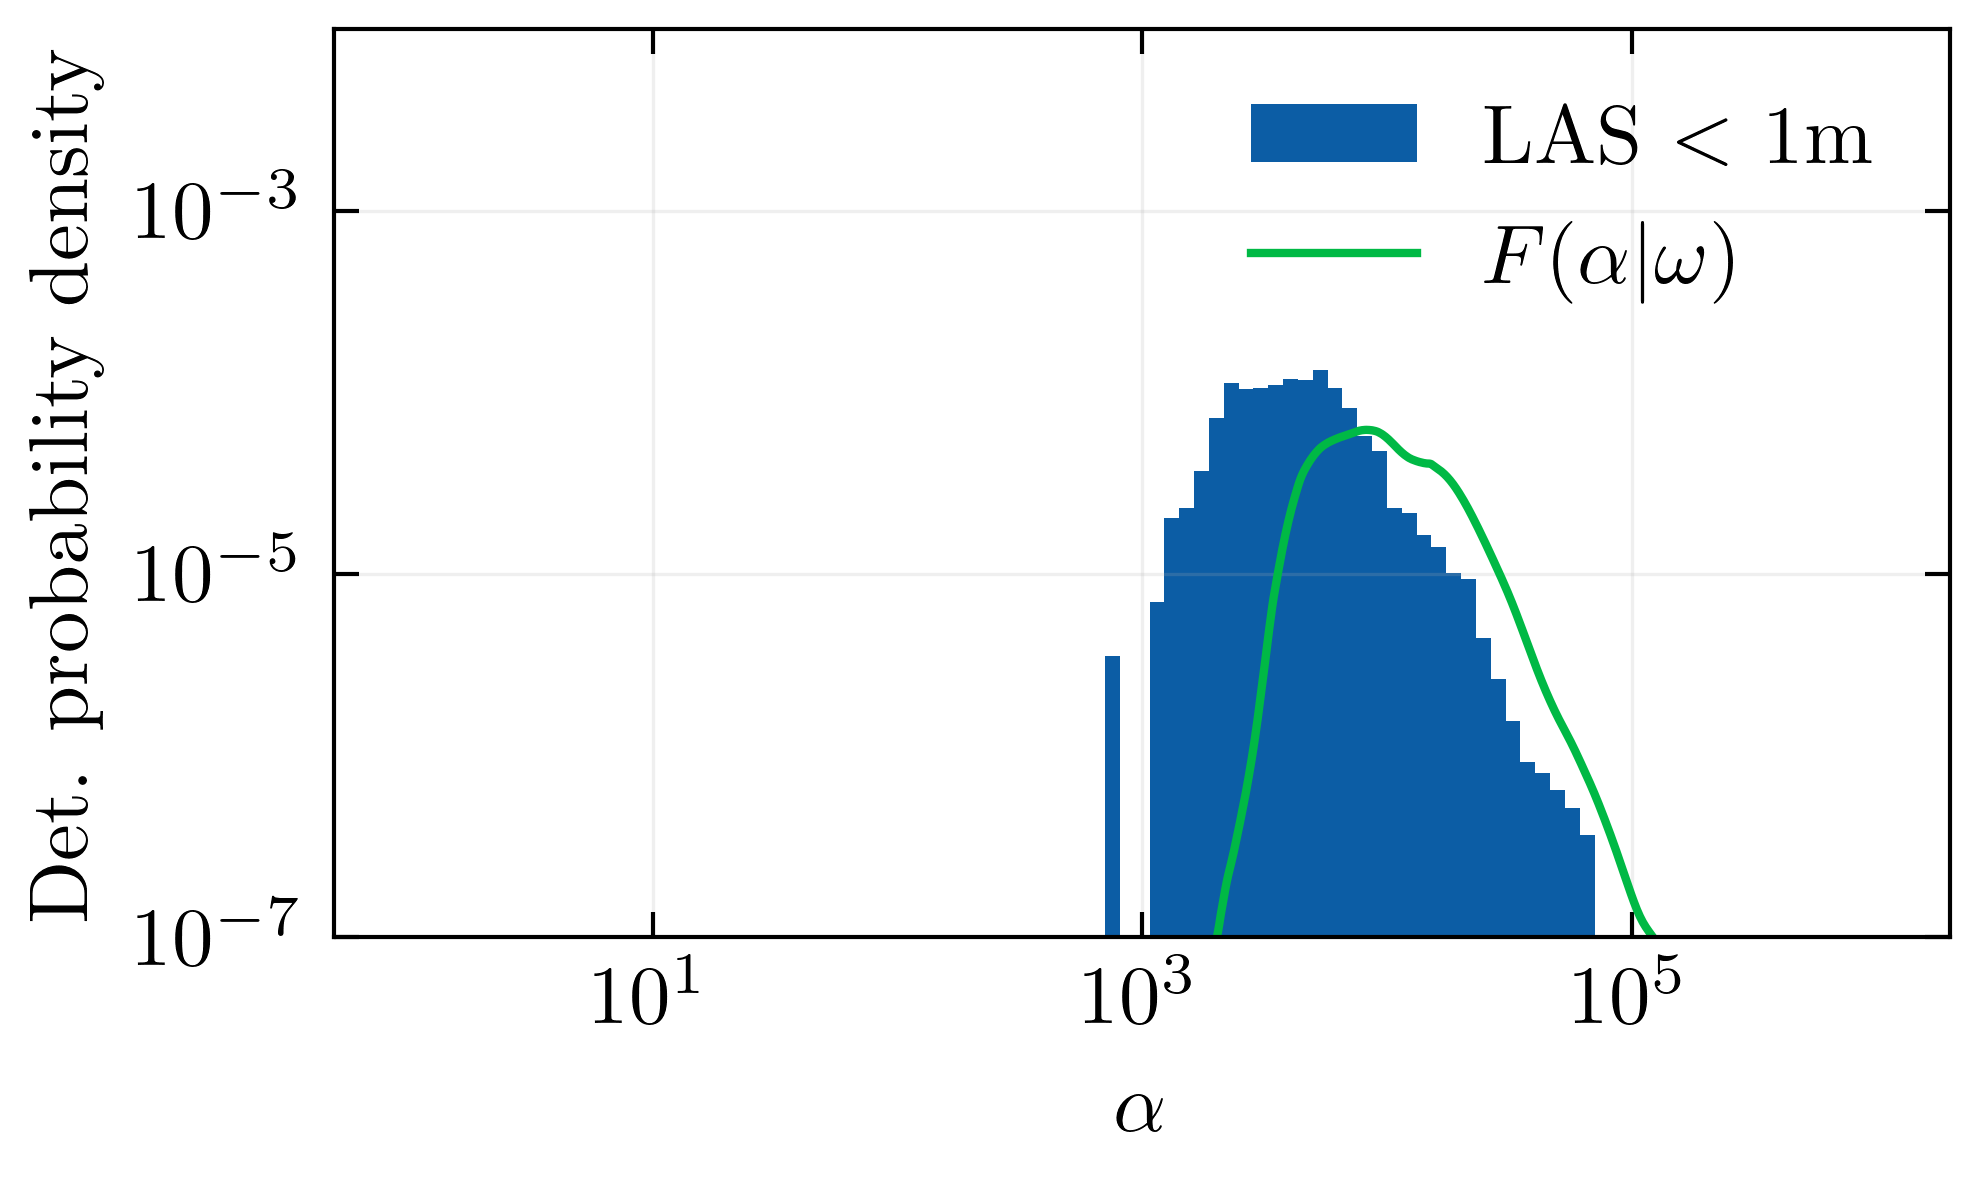

In [12]:
fit_alphas = cleaned_data.collect()["alpha"].to_numpy()

plt.hist(fit_alphas, alphas_hist, density = True, label = r"LAS $<$ 1m")
plt.plot(alphas, F_norm(alphas, 0.45, 0.9, 2.5 / 2), label = r"$F(\alpha|\omega)$")
plt.ylim(1e-7, 1e-2)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.savefig("overall_fit.png")
plt.tight_layout()
plt.show()

In [13]:
from statsmodels.base.model import GenericLikelihoodModel

class TheoryFit(GenericLikelihoodModel):
    param_names = ["e", "g", "q"]

    def __init__(self, x):
        super().__init__(x)

    def loglikeobs(self, params):
        x = self.endog
        print(f"Ran iteration with params {params}")
        return np.log(F_norm(x, *params))

    @property
    def start_params(self):
        return np.array([0.45, 0.5, 3 / 2])
    
mle_model = TheoryFit(cleaned_data.collect()["alpha"].to_numpy()).fit()

Ran iteration with params [0.45 0.5  1.5 ]


C:\Users\Joshu\AppData\Local\Temp\ipykernel_28536\740708052.py:25: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return integrate.quad(transformed, np.log(a), np.log(b), limit=200, epsabs=1e-10, epsrel=1e-10)


Ran iteration with params [0.4725 0.5    1.5   ]
Ran iteration with params [0.45  0.525 1.5  ]
Ran iteration with params [0.45  0.5   1.575]
Ran iteration with params [0.465 0.475 1.55 ]
Ran iteration with params [0.4725 0.45   1.575 ]
Ran iteration with params [0.48       0.46666667 1.6       ]
Ran iteration with params [0.4625     0.44444444 1.66666667]
Ran iteration with params [0.49333333 0.40740741 1.65277778]


C:\Users\Joshu\AppData\Local\Temp\ipykernel_28536\2574541375.py:12: RuntimeWarning: divide by zero encountered in log
  return np.log(F_norm(x, *params))


Ran iteration with params [0.46083333 0.47685185 1.59444444]
Ran iteration with params [0.4825     0.43055556 1.63333333]
Ran iteration with params [0.465      0.41666667 1.65      ]
Ran iteration with params [0.47625    0.45416667 1.6125    ]
Ran iteration with params [0.49166667 0.44537037 1.54722222]
Ran iteration with params [0.50625    0.44583333 1.4875    ]
Ran iteration with params [0.4875     0.46944444 1.48333333]
Ran iteration with params [0.48375    0.44027778 1.59583333]
Ran iteration with params [0.49875    0.43657407 1.49305556]
Ran iteration with params [0.51       0.42777778 1.43333333]
Ran iteration with params [0.52       0.43179012 1.47592593]
Ran iteration with params [0.54375    0.42268519 1.42638889]
Ran iteration with params [0.53291667 0.43585391 1.37515432]
Ran iteration with params [0.52819444 0.4236454  1.40859053]
Ran iteration with params [0.51173611 0.44028635 1.46777263]
Ran iteration with params [0.48740741 0.43657979 1.58268176]
Ran iteration with param

In [14]:
print(mle_model.summary())
# AIC 1.018e+06 - 1m
# AIC 1.080e5 - 3m

Ran iteration with params [0.5444464  0.42797344 1.42532478]
                              TheoryFit Results                               
Dep. Variable:                      y   Log-Likelihood:                -26462.
Model:                      TheoryFit   AIC:                         5.294e+04
Method:            Maximum Likelihood   BIC:                         5.297e+04
Date:                Tue, 14 Apr 2026                                         
Time:                        23:25:07                                         
No. Observations:                2675                                         
Df Residuals:                    2672                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0           0.5444      0.134      4.053      0.000       0.281    

C:\Users\Joshu\AppData\Local\Temp\ipykernel_28536\740708052.py:25: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return integrate.quad(transformed, np.log(a), np.log(b), limit=200, epsabs=1e-10, epsrel=1e-10)


C:\Users\Joshu\AppData\Local\Temp\ipykernel_28536\740708052.py:25: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return integrate.quad(transformed, np.log(a), np.log(b), limit=200, epsabs=1e-10, epsrel=1e-10)


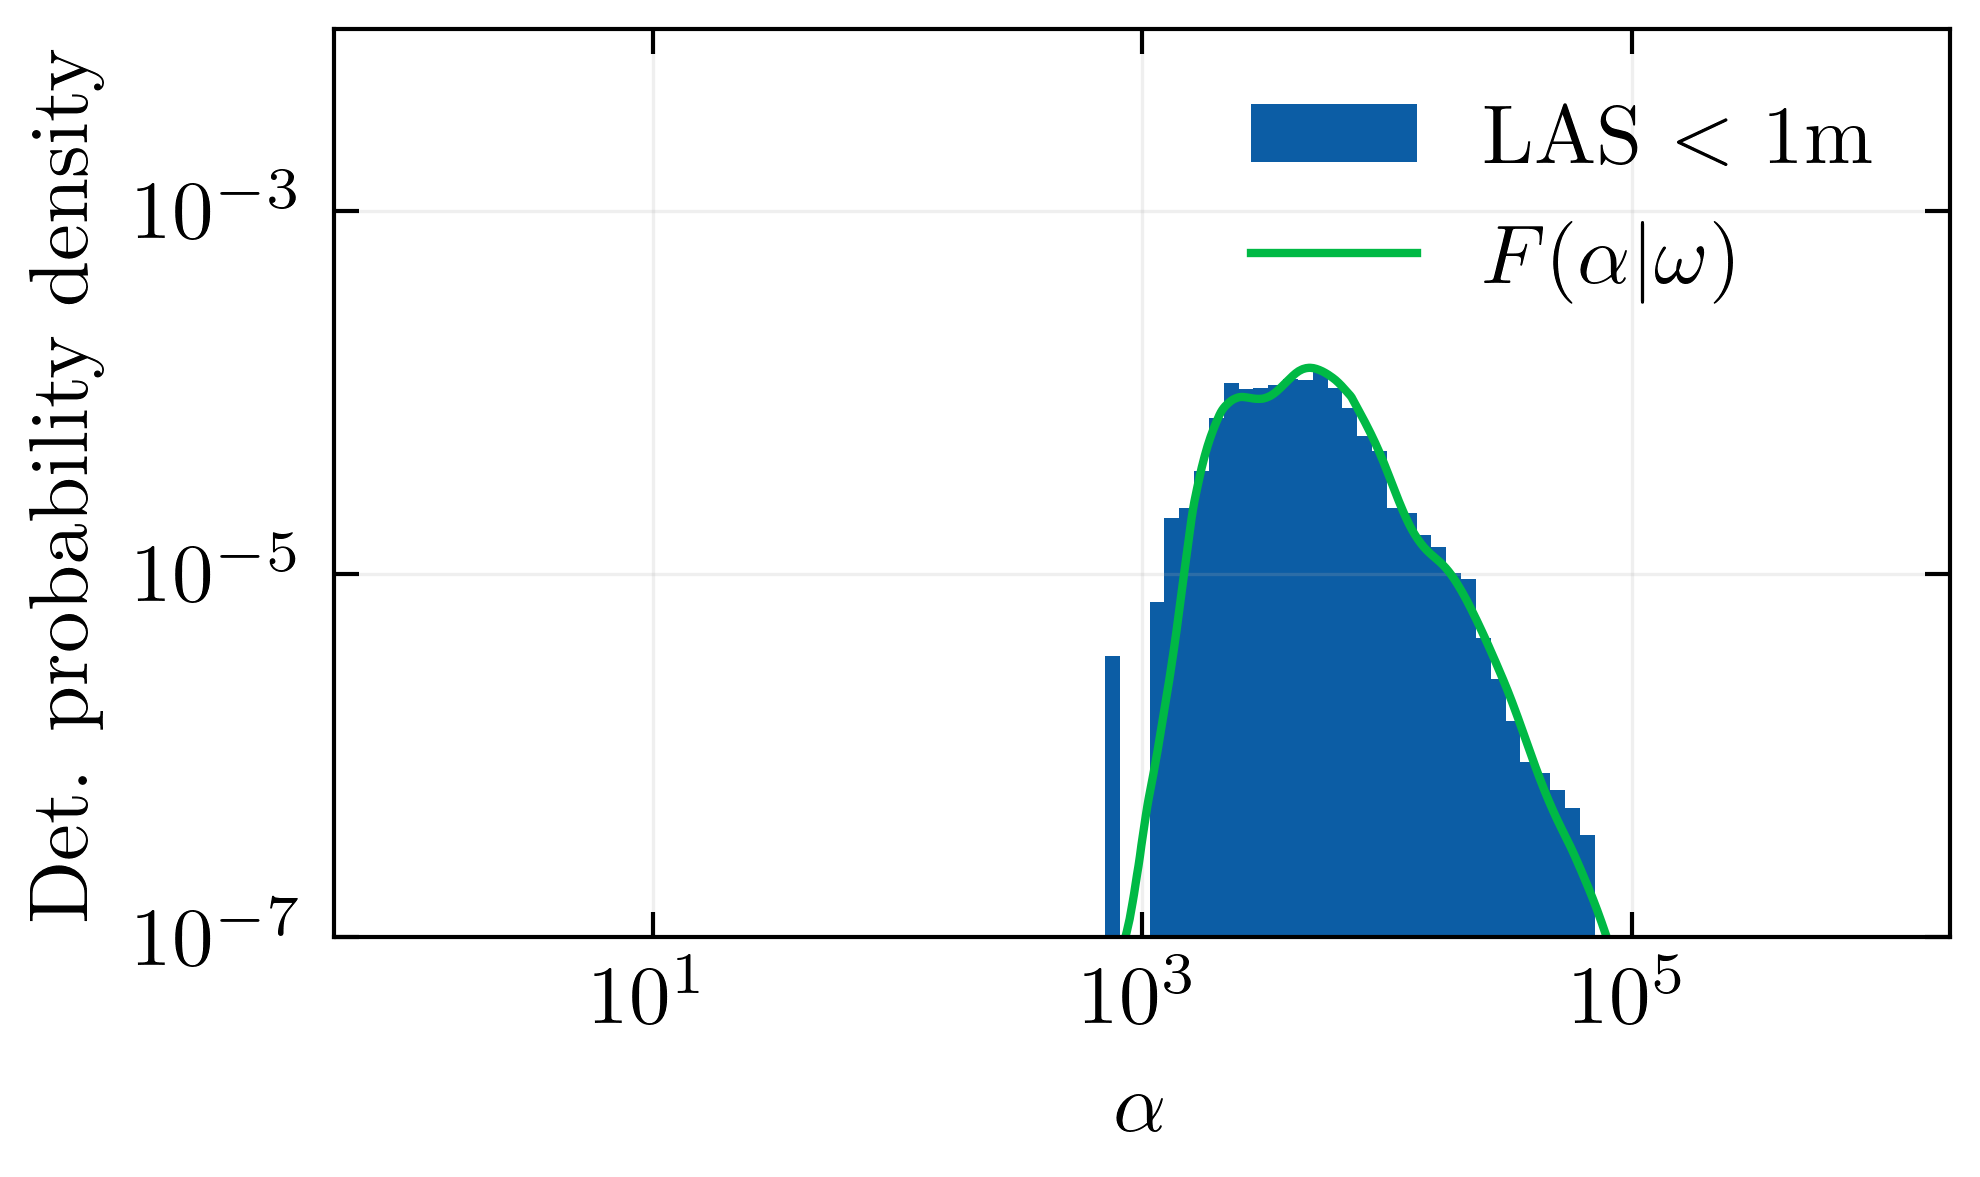

In [15]:
plt.hist(cleaned_data.collect()["alpha"].to_numpy(), alphas_hist, density = True, label = r"LAS $<$ 1m")
plt.plot(alphas, F_norm(alphas,  *mle_model.params), label = r"$F(\alpha|\omega)$")
plt.ylim(1e-7, 1e-2)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.savefig("overall_fit.png")
plt.tight_layout()
plt.show()

12.864067077636719


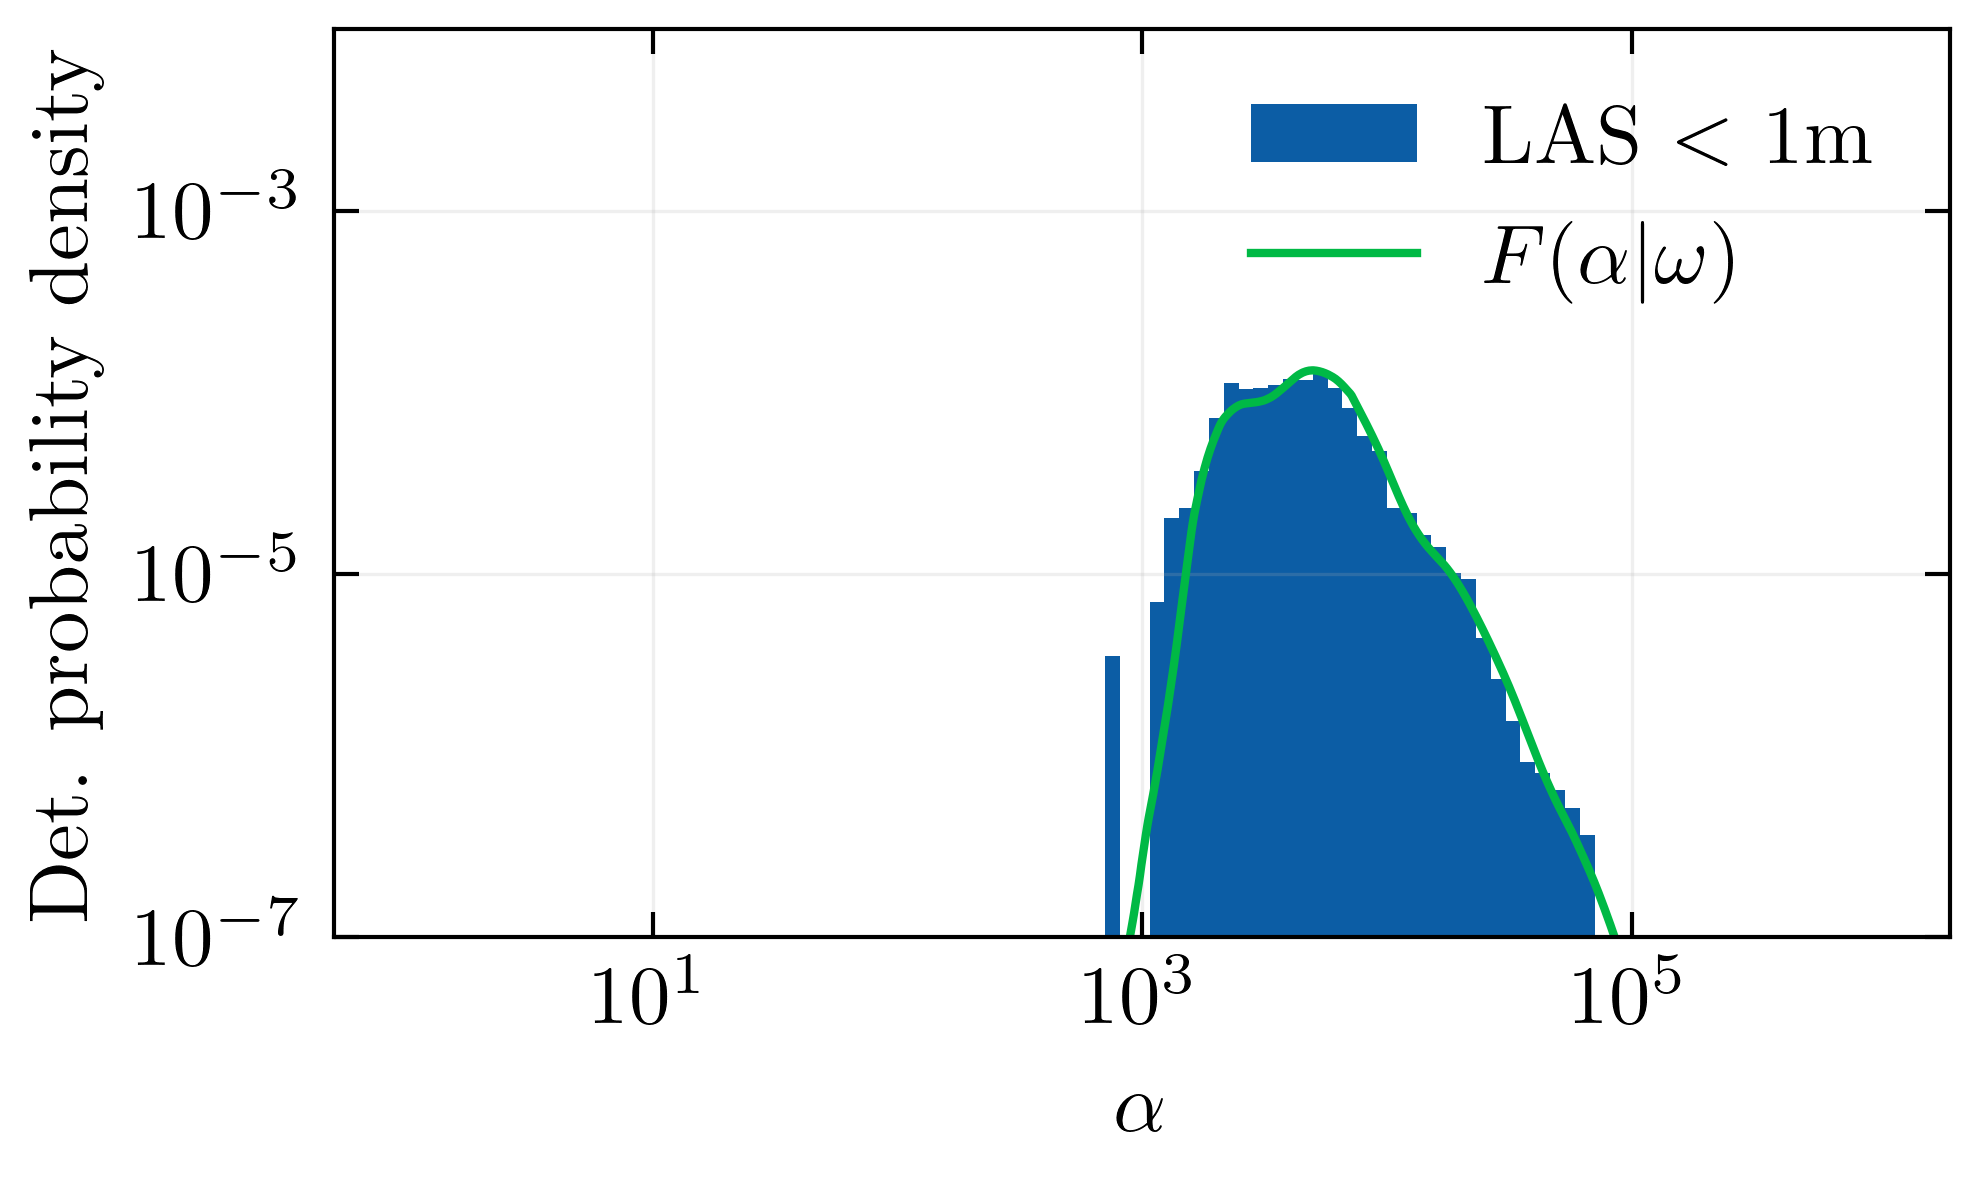

In [17]:
from quick_calculate import FittingFunction

fit = FittingFunction(LAD_min = 4)

plt.hist(cleaned_data.collect()["alpha"].to_numpy(), alphas_hist, density = True, label = r"LAS $<$ 1m")
plt.plot(alphas, fit.F_norm(alphas, *mle_model.params), label = r"$F(\alpha|\omega)$")
plt.ylim(1e-7, 1e-2)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.savefig("overall_fit.png")
plt.tight_layout()
plt.show()

0.6819992065429688


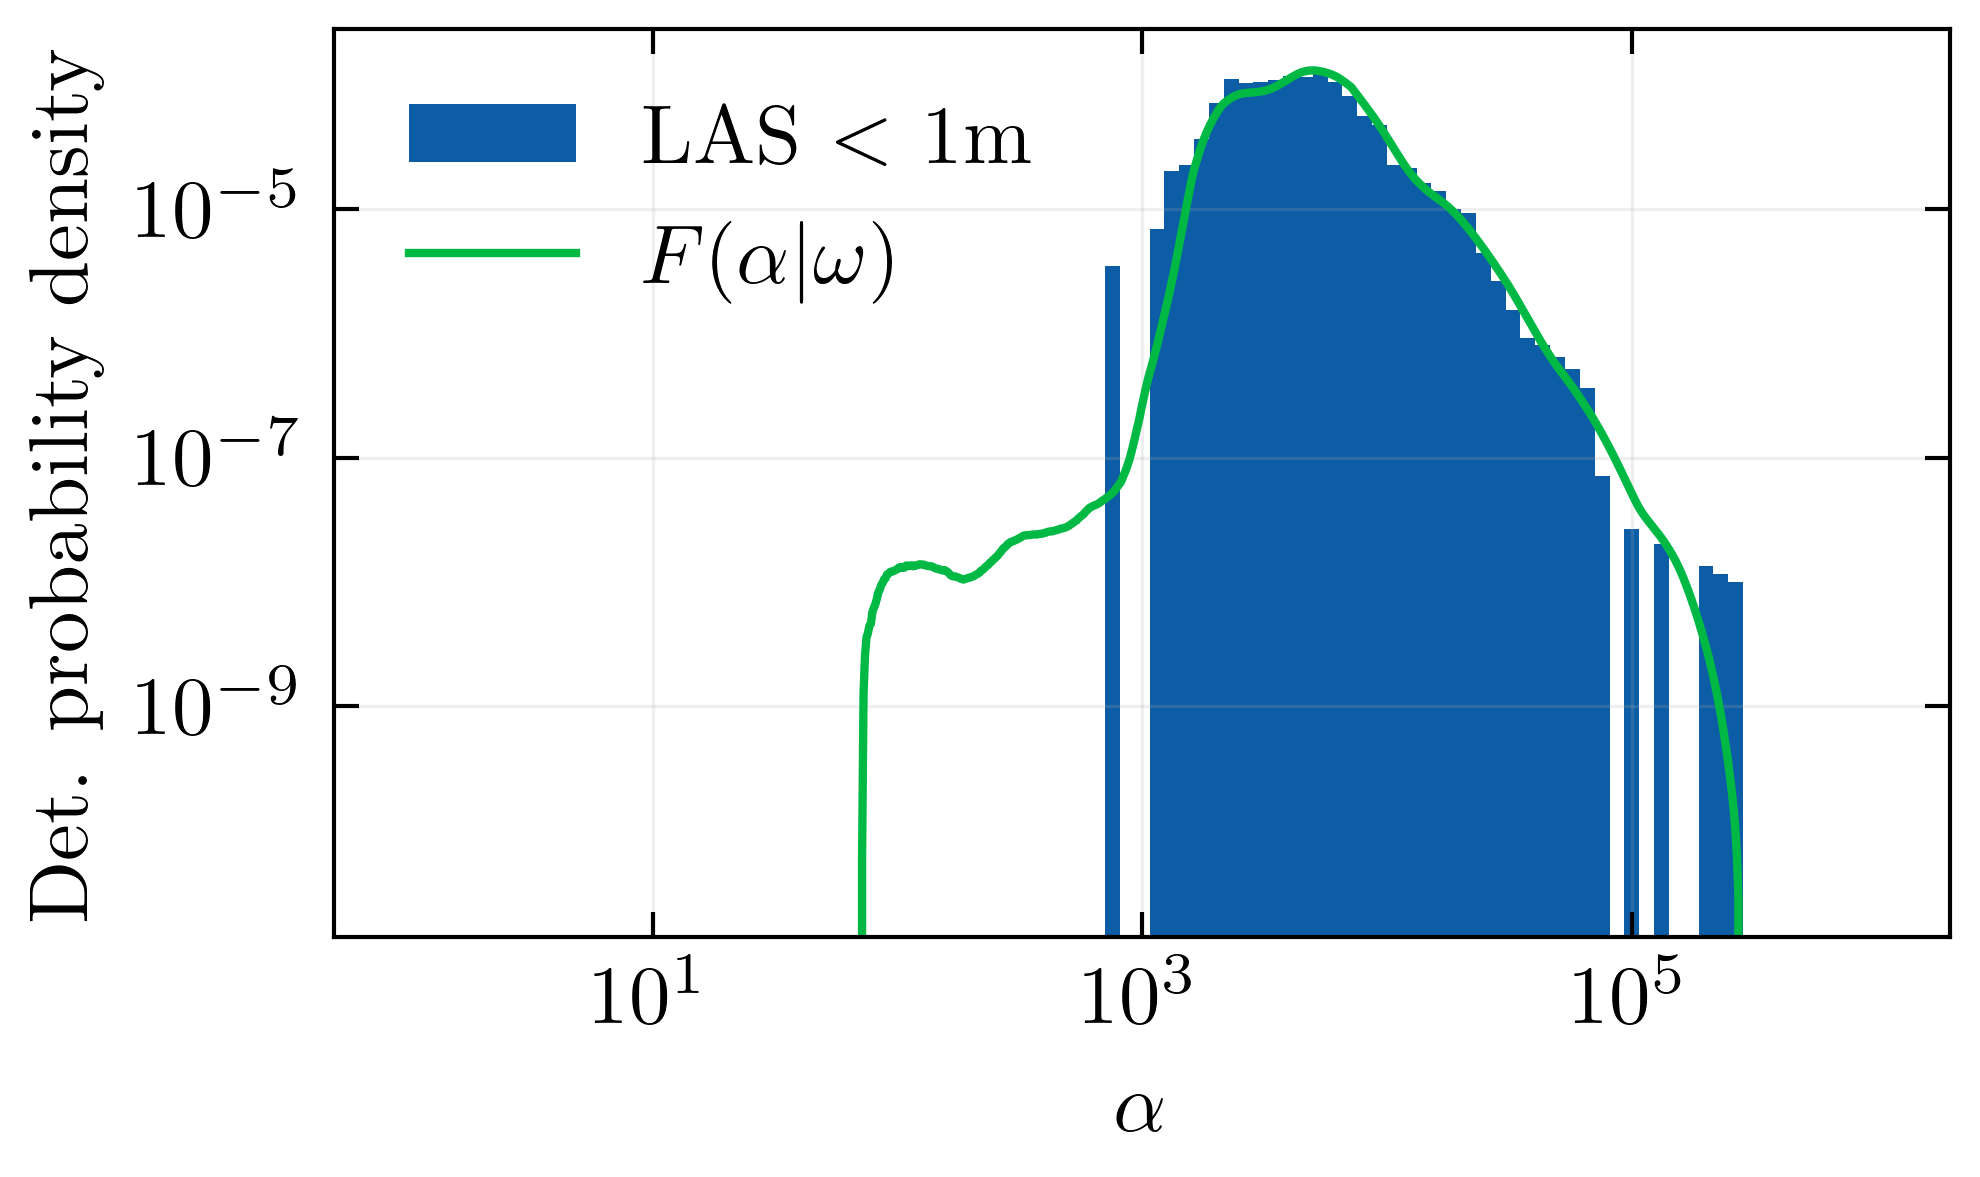

In [20]:
plt.hist(cleaned_data.collect()["alpha"].to_numpy(), alphas_hist, density = True, label = r"LAS $<$ 1m")
plt.plot(alphas, fit.F_norm(alphas, *mle_model.params), label = r"$F(\alpha|\omega)$")
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.savefig("overall_fit.png")
plt.tight_layout()
plt.show()